# **Anipose experimental data**

Reproduce plots and analyses of joint kinematics from Anipose-tracked tethered headless flies under CsChrimson
optogenetic activation. Data used:

- `grant--rv18-BDN2-gal4xUAS-CsChrimson-headless_processed_2025-06-20_processed-freqs.pq` —
  DNg100>CsChrimson, **Fig 2h–j**
- `grant--rv18-SS70620-gal4xUAS-CsChrimson-headless-offball_processed-freqs.pq` —
  DNb08 (SS70620)>CsChrimson, **Fig 5d–e**

In [1]:
dataPath = "/data/users/smpuglie/Pugliese26_published/anipose/"

# Setup

In [2]:
## imports
import matplotlib.pyplot as plt
from src.utils.plot_utils import *
from src.utils.sim_utils import *
from src.utils.sim_utils import neuron_oscillation_score  # not re-exported by src.utils
import numpy as np
import pandas as pd
import seaborn as sns
import jax
import jax.numpy as jnp
from scipy import stats, signal
from datetime import date
from tqdm import tqdm

## plotting defaults
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["axes.spines.right"] = "False"
plt.rcParams["axes.spines.top"] = "False"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["figure.figsize"] = (2,2)
plt.rcParams['axes.linewidth'] = 0.25
plt.rcParams["xtick.major.size"] = 1.7
plt.rcParams["ytick.major.size"] = 1.7
plt.rcParams["xtick.major.width"] = 0.25
plt.rcParams["ytick.major.width"] = 0.25
plt.rcParams["figure.dpi"] = 200

SMALL_SIZE = 6
LABEL_SIZE = 7
AXLABEL_SIZE = 8
TITLE_SIZE = 10

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=AXLABEL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=LABEL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=TITLE_SIZE)  # fontsize of the figure title

# the other figure notebooks use 1.5 here; these panels were sized against 2.0
plt.rcParams["axes.labelpad"] = 2.0
plt.rcParams["xtick.major.pad"] = 2.0
plt.rcParams["ytick.major.pad"] = 2.0

moduleColors = get_module_colors()

dnColor = "#51bbad"
excColor = "#d84a2e"
inhColor = "#026b85"
mnColor = "#267655"

lightDnColor = "#a7dcd5ff"
lightExcColor = "#ff9985"

## dataset constants
fps = 300

legs = ['L1','R1','L2','R2','L3','R3']
angles = ['A_flex','A_abduct','A_rot','B_flex','B_rot','C_flex','C_rot','D_flex']
positions = ['E_x','E_y','E_z']

label_dict = {'A_abduct':'coxa abduction (°)', 'A_flex':'coxa flexion (°)',  'A_rot':'coxa rotation (°)', 
              'B_flex':'femur flexion (°)','B_rot':'femur rotation (°)', 
              'C_flex':'tibia flexion (°)', 'C_rot':'tibia rotation (°)', 'D_flex':'tarsus flexion (°)', 
              'E_x':'lateral position','E_y':'longitudinal position', 'E_z':'vertical position',
              'fictrac_delta_rot_lab_y_mms':'Forward velocity (mm/s)', 
              'fictrac_delta_rot_lab_z_deg/s':'Turning velocity (°/s)'}

Using diffeqsolve-based neural simulation (original)


Load data.

The source files carry 677 / 646 columns; the analyses below touch ~73 of them, so read only those
(loading everything needs ~13 GB / ~5 GB of RAM instead of ~1.4 GB / ~0.6 GB). DNb08 was recorded
off-ball, so that file has no `fictrac_*` columns at all — forward velocity is only used for the
DNg100 panels.

In [3]:
metaCols = ['fullfile', 'fly', 'flyid', 'mW', 'stimlen', 'fnum']
columnsNeeded = (metaCols
                 + [leg+ang for leg in legs for ang in angles]
                 + [leg+pos for leg in legs for pos in positions])

# DNb08 was recorded off-ball, so it has no fictrac columns
dng100 = pd.read_parquet(
    dataPath + 'grant--rv18-BDN2-gal4xUAS-CsChrimson-headless_processed_2025-06-20_processed-freqs.pq',
    columns=columnsNeeded + ['fictrac_delta_rot_lab_y_mms'])
dnb08 = pd.read_parquet(
    dataPath + 'grant--rv18-SS70620-gal4xUAS-CsChrimson-headless-offball_processed-freqs.pq',
    columns=columnsNeeded)

print(dng100.shape, dnb08.shape)

(2592000, 73) (1080000, 72)


## functions

In [4]:
def set_filters(df,preS,stimS,postS,fps=fps):
    pre = df['fnum'] < preS*fps
    during = (df['fnum'] >= preS*fps) & (df['fnum'] < (preS+stimS)*fps)
    # note: trials are exactly (preS+stimS+postS)*fps frames long, so `post` is always empty.
    # It is unused by the analyses below; left as-is rather than silently changing the filter.
    post = df['fnum'] >= (preS+stimS+postS)*fps
    exp = df['stimlen'] == stimS
    
    return pre, during, post, exp

def plot_traces(df, flyid, leg, feature, trialNums = "all", xticks=[0,5,10,15], yticks=None, savepath='', **kwargs):
    pre, during, post, exp = set_filters(df,5,5,5)
    
    is_flyid = df['flyid'] == flyid

    if trialNums == "all":
        trials = df.loc[(exp & is_flyid), 'fullfile'].unique()
    else:
        trials = df.loc[is_flyid, 'fullfile'].unique()[trialNums]
    
    fig, ax = plt.subplots(trials.size, 1, sharex=True, sharey=True)
    
    y = leg+feature

    for i, vid in enumerate(trials):
        if len(trials)>1:
            axi = ax[i]
        else:
            axi = ax
        is_trial = df['fullfile'] == vid
        axi.plot(df.loc[is_trial,'fnum']/fps, df.loc[is_trial, y].abs(), **kwargs)
        if '5 sec' in vid:
            axi.axvspan(5,10, color='#f55c66ff', alpha=0.25)
        else:
            axi.axvspan(1,4, color='#f55c66ff', alpha=0.25)
        
        axi.set_xlim(0,15)
        if xticks is not None:
            axi.set_xticks(xticks)
        
        if yticks is not None:
            axi.set_yticks(yticks)

    sns.despine()
    axi.set_xlabel('Time (s)')
    fig.supylabel(f'{leg} {label_dict[feature]}')
    plt.tight_layout()

    if len(savepath) > 0:
        plt.savefig(savepath, dpi=200)

def compute_pd_freqs(df, flies, leg, ang, prom, dist, fps=fps):
    
    pre, during, post, exp = set_filters(df,5,5,5)
    in_flies = df['fly'].isin(flies)
    
    angle_stats = pd.DataFrame(columns=['fly','fullfile','stepnum','mW','freq'])
    flyList = []
    fnames = []
    mW = []
    steps = []
    freqs = []
    amps = []
    velos = []
    
    for trial in tqdm(df.loc[exp & in_flies, 'fullfile'].unique()):
        is_trial = df['fullfile'] == trial
        angle = df.loc[is_trial & during, leg+ang].to_numpy()
        velo = df.loc[is_trial & during, 'fictrac_delta_rot_lab_y_mms'].to_numpy()

        peaks = signal.find_peaks(angle, prominence=prom, distance=dist)[0] 
        troughs = signal.find_peaks(-angle, prominence=prom, distance=dist)[0]
        
        if peaks.size < 1: #or troughs.size < 3:
            continue
        elif peaks.size > troughs.size:
            peaks = peaks[:len(troughs)]
        elif peaks.size < troughs.size:
            troughs = troughs[:len(peaks)]
        
        if peaks.size != troughs.size:
            print(peaks.size, troughs.size)
        
        period = np.diff(peaks) 
        freq = 1/period * fps
        amp = angle[peaks] - angle[troughs]
        amp = amp[1:]
        v = (velo[peaks] + velo[troughs]) / 2
        v = v[1:]

        fly = [df.loc[is_trial, 'fly'].iloc[0]] * freq.size
        fullfile = [trial]*freq.size
        stepnums = np.arange(freq.size)
        pwr = [df.loc[is_trial, 'mW'].iloc[0]] * freq.size

        freqs.extend(freq)
        amps.extend(amp)
        velos.extend(v)
        flyList.extend(fly)
        fnames.extend(fullfile)
        steps.extend(stepnums)
        mW.extend(pwr)
        
    angle_stats['fly'] = flyList
    angle_stats['fullfile'] = fnames
    angle_stats['stepnum'] = steps
    angle_stats['mW'] = mW
    angle_stats['freq'] = freqs
    angle_stats['amp'] = amps
    angle_stats['fwd_velo'] = velos

    return angle_stats

def plot_trial_avg(df, leg, feature, flies, intensities, figsize, colors, xticks, yticks, savepath, ylab='',linewidth=0.75):
    pre, during, post, exp = set_filters(df,5,5,5)
    
    fig = plt.figure(figsize=figsize)
    ax = plt.axes()

    is_batch = df['fly'].isin(flies)

    dfs = []
    for stim in intensities:
        is_stim = df['mW'] == stim
        dfs.append(df.loc[is_stim & exp & is_batch])

    for c, d in enumerate(dfs):
        d = d.reset_index(drop=True)
        plot_df = d

        plot_df['fnum_copy'] = plot_df['fnum']

        time_bins = np.arange(0,4501,50)
        step_time_bins = pd.cut(plot_df[f'fnum_copy'].sort_values(), time_bins)
        intervals = step_time_bins.dropna().unique()

        mean = np.array([])
        std = np.array([])
        low_ci = np.array([])
        high_ci = np.array([])
        time = np.array([])

        n_flies = plot_df['fly'].unique().size
        print(f'Intensity: {intensities[c]} mW, N = {n_flies} flies')

        # this does not depend on the interval, so compute it once instead of once per bin
        groupby = plot_df.groupby(['fly',step_time_bins],observed=False)[[leg+feature, 'fnum']].agg(['mean','std','count']).reset_index()

        for i in range(len(intervals)):
            pb = groupby.loc[groupby['fnum_copy'] == intervals[i]]
            bin_mean = pb[(leg+feature,'mean')].mean()
            mean = np.append(mean, bin_mean)

            bin_std = pb[(leg+feature,'std')].mean()
            std = np.append(std, bin_std)

            bin_low_ci = bin_mean - 1.96 * bin_std / n_flies
            bin_high_ci = bin_mean + 1.96 * bin_std / n_flies
            low_ci = np.append(low_ci, bin_low_ci)
            high_ci = np.append(high_ci, bin_high_ci)

            bin_time = pb[('fnum','mean')].mean()
            time = np.append(time, intervals[i].left)

        ax.plot(time/fps, mean, color=colors[c], label=intensities[c],linewidth=linewidth)
        ax.fill_between(time/fps, low_ci, high_ci, color=colors[c], alpha=0.1)

    ax.set_xlim(xticks[0]-0.5, xticks[-1])
    ax.set_xticks(xticks)
    ax.set_ylim(yticks[0]-0.5, yticks[-1])
    ax.set_yticks(yticks)

    sns.despine()
    
    fig.supxlabel('Time (s)')
    try:
        fig.supylabel(f'{label_dict[feature].capitalize()}\n')
    except:
        fig.supylabel(f'{ylab}\n')
        
    fig.legend(title=r'Intensity (mW/mm$^{2}$)',loc="upper center",bbox_to_anchor=[1,0],edgecolor="None",facecolor="None")
    
    if len(savepath) > 0:
        plt.savefig(savepath, dpi=200)

# DNg100>CsChrimson example traces

In [5]:
pre, during, post, exp = set_filters(dng100,5,5,5)

(np.float64(35.0), np.float64(95.0))


<Figure size 400x400 with 0 Axes>

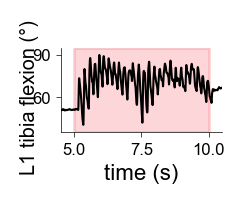

In [6]:
figFolder = "../figures/anipose-plots-" + date.today().strftime("%Y%m%d")

flyid = '3.6.25 Fly 2_1' 
leg = 'L1'
feature='C_flex'
trialNums = [2]
xticks = np.arange(0,15,2.5)
yticks=[60,90]

savepath=''

plt.figure()
plot_traces(dng100, flyid, leg, feature, trialNums, xticks, yticks, savepath, color="k",linewidth=0.75)
plt.xlabel("time (s)")
plt.xlim([4.5,10.5])
plt.ylim([35,95])
plt.subplots_adjust(hspace=0)
plt.gcf().set_figheight(0.54)
plt.gcf().set_figwidth(1.08)
print(plt.gca().get_ylim())

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/DNg100_fly{flyid[-3:]}_{leg}{feature}.svg",transparent=True)

(np.float64(20.0), np.float64(80.0))


<Figure size 400x400 with 0 Axes>

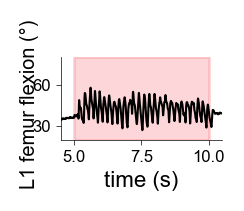

In [7]:
flyid = '3.6.25 Fly 2_1' 
leg = 'L1'
feature='B_flex'
trialNums = [2]
xticks = np.arange(0,15,2.5)
yticks=[30,60,90]

savepath=''

plt.figure()
plot_traces(dng100, flyid, leg, feature, trialNums, xticks, yticks, savepath, color="k",linewidth=0.75)
plt.xlabel("time (s)")
plt.xlim([4.5,10.5])
plt.ylim([20,80])
plt.subplots_adjust(hspace=0)
plt.gcf().set_figheight(0.54)
plt.gcf().set_figwidth(1.08)
print(plt.gca().get_ylim())

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/DNg100_fly{flyid[-3:]}_{leg}{feature}.svg",transparent=True)

# DNg100>CsChrimson stepping frequency

Compute frequencies:

In [8]:
leg = 'L1'
ang = 'E_y'
march_flies = dng100['fly'].str.contains(r'3\.')
flies = dng100.loc[march_flies, 'fly'].unique()
intensities = ['0.029', '0.086','0.329']
colors = sns.blend_palette(["#388ec3ff","#faaa21ff"],n_colors=len(intensities))
xticks = [0,5,10,15]
yticks = [0,1,2,3,4,5]
savepath = ''

prom = 0.15
dist = 15

dng100AngleStats = compute_pd_freqs(dng100, flies, leg, ang, prom, dist, fps=fps)

non_transient = dng100AngleStats['stepnum'] >= 1
transient = (dng100AngleStats['stepnum'] >= 0) & (dng100AngleStats['stepnum'] < 2)
order = ['0.029','0.086','0.329']

group = dng100AngleStats.loc[non_transient].groupby(['fly','mW'])[['freq','amp','fwd_velo']].mean().reset_index()


  0%|          | 0/232 [00:00<?, ?it/s]


  0%|          | 1/232 [00:00<00:29,  7.91it/s]


  1%|          | 2/232 [00:00<00:31,  7.27it/s]


  1%|▏         | 3/232 [00:00<00:29,  7.79it/s]


  2%|▏         | 4/232 [00:00<00:28,  7.87it/s]

...


 99%|█████████▊| 229/232 [00:27<00:00,  8.01it/s]


 99%|█████████▉| 230/232 [00:28<00:00,  8.10it/s]


100%|█████████▉| 231/232 [00:28<00:00,  8.04it/s]


100%|██████████| 232/232 [00:28<00:00,  8.13it/s]


100%|██████████| 232/232 [00:28<00:00,  8.19it/s]

Plot:

/tmp/ipykernel_3466695/1340904928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=group,x='mW',y='freq',size=2**0.75,palette=colors,order=order,jitter=0.3)
/tmp/ipykernel_3466695/1340904928.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=group,x='mW',y='freq',edgecolor="none",inner=None,alpha=0.4,palette=colors,order=order,width=0.9,cut=0)


/tmp/ipykernel_3466695/1340904928.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['{:.2f}'.format(float(s.get_text())) for s in ax.get_xticklabels()])


(0.0, 8.0)

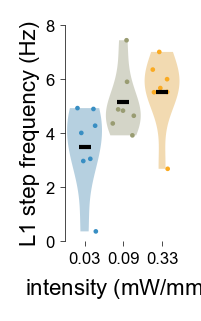

In [9]:
plt.figure(figsize=(0.75,1.4))

order = ['0.029','0.086','0.329']

sns.stripplot(data=group,x='mW',y='freq',size=2**0.75,palette=colors,order=order,jitter=0.3)


sns.violinplot(data=group,x='mW',y='freq',edgecolor="none",inner=None,alpha=0.4,palette=colors,order=order,width=0.9,cut=0)
sns.pointplot(data=group,x='mW',y='freq',color="k",orient="v",errorbar=None,marker="_",order=order,
              markersize=4,markeredgewidth=1.5,linestyle="none",zorder=10)

sns.despine()
ax = plt.gca()
try:
    ax.get_legend().remove()
except:
    pass
ax.set_xlabel('intensity (mW/mm$^2$)')
ax.set_ylabel(f'{leg} step frequency (Hz)')
ax.set_xticklabels(['{:.2f}'.format(float(s.get_text())) for s in ax.get_xticklabels()])
ax.spines["bottom"].set_visible(False)
plt.ylim([0,8])

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/DNg100_{leg}{ang}_steppingFreq-wMeans.svg",transparent=True)

In [10]:
lowStimFreqs = group.loc[group["mW"]=="0.029","freq"]
medStimFreqs = group.loc[group["mW"]=="0.086","freq"]
highStimFreqs = group.loc[group["mW"]=="0.329","freq"]

print(f"n flies per intensity: {lowStimFreqs.size}, {medStimFreqs.size}, {highStimFreqs.size}")

n flies per intensity: 7, 7, 7


Both an independent and a paired t-test were run on the low vs. medium intensity groups in the
original analysis; the paired test is only valid if every fly contributes to both groups (equal
sizes, matched order). Both are kept below — pick whichever matches the intended design.

In [11]:
stats.ttest_ind(lowStimFreqs,medStimFreqs)

TtestResult(statistic=np.float64(-2.1921654773460415), pvalue=np.float64(0.048817991651551575), df=np.float64(12.0))

In [12]:
stats.ttest_rel(lowStimFreqs,medStimFreqs)

TtestResult(statistic=np.float64(-2.7824595826312826), pvalue=np.float64(0.03189328016509558), df=np.int64(6))

# DNg100>CsChrimson forward velocity

Intensity: 0.029 mW, N = 7 flies
Intensity: 0.086 mW, N = 7 flies


Intensity: 0.329 mW, N = 7 flies


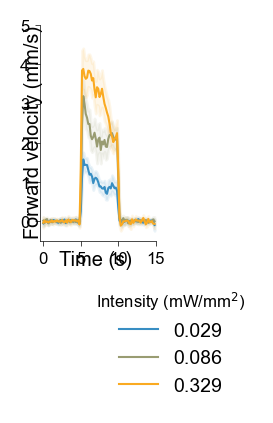

In [13]:
leg = ''
feature = 'fictrac_delta_rot_lab_y_mms'
march_flies = dng100['fly'].str.contains(r'3\.')
flies = dng100.loc[march_flies, 'fly'].unique()
intensities = ['0.029', '0.086','0.329']
figsize = (0.75,1.4)
colors = sns.blend_palette(["#388ec3ff","#faaa21ff"],n_colors=len(intensities))
xticks = [0,5,10,15]
yticks = [0,1,2,3,4,5]
savepath = ''


plot_trial_avg(dng100, leg, feature, flies, intensities, figsize, colors, xticks, yticks, savepath)
fig = plt.gcf()

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/DNg100_{feature}_{len(intensities)}intensities_trialAverage.svg",transparent=True)

# DNb08>CsChrimson example traces

(np.float64(35.10047266000642), np.float64(183.5483032033951))


(-10.0, 190.0)

<Figure size 400x400 with 0 Axes>

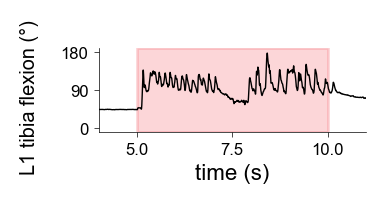

In [14]:
flyid = "4.30.25 Fly 3_1"
leg = 'L1'
feature='C_flex'
trialNums=[4]
xticks=np.arange(0,15,2.5)
yticks=None
savepath=''

plt.figure()
plot_traces(dnb08, flyid, leg, feature, trialNums, xticks, yticks, savepath, color="k",linewidth=0.5)
plt.xlabel("time (s)")
plt.xlim([4,11])
plt.subplots_adjust(hspace=0)
plt.gcf().set_figheight(0.54)
print(plt.gca().get_ylim())

plt.gcf().set_figwidth(1.85)
plt.yticks([0,90,180])
plt.ylim([-10,190])

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/DNb08--{str.replace(flyid,' ','')}_{leg}{feature}.svg",transparent=True)

# DNb08 kinematic rhythmicity

`neuron_oscillation_score` (`src.utils.sim_utils`) is the same autocorrelation-based score used
to evaluate the network simulations, so behavioral and simulated rhythmicity are directly
comparable. It returns `(score, frequency)`, with the **frequency in cycles per sample** — multiply
by `fps` to get Hz.

Each trial contributes one score per leg joint angle, computed on a 2 s window starting 0.5 s into
the stimulus period. Traces whose detected period is longer than the cutoff (i.e. fewer than a
couple of cycles in the window) are not meaningfully rhythmic, so they are zeroed; both cutoffs
used in the original analysis are reported below.

In [15]:
# vmap over the 48 (leg, angle) traces of a trial at once
score_traces = jax.jit(jax.vmap(neuron_oscillation_score, in_axes=(0, None)))

scoreCols = [leg+ang for leg in legs for ang in angles]


def compute_rhythmicity_scores(df, minFreqHz, fps=fps, start=0.5, end=2.5,
                               prominence=0.2, mW="0.329"):
    """Rhythmicity score and frequency per leg joint angle, one row per trial.

    Scores are computed on df[start:end] seconds into the stimulus window. Traces whose detected
    frequency falls below `minFreqHz` are zeroed. Trials at intensities other than `mW` are kept
    as rows but left unscored.
    """
    pre, during, post, exp = set_filters(df, 5, 5, 5)
    rows = []

    for trial in tqdm(df['fullfile'].unique()):
        isTrial = df['fullfile'] == trial
        row = {"trial": trial,
               "flyid": df.loc[isTrial, "flyid"].iloc[0],
               "mW": df.loc[isTrial, "mW"].iloc[0]}

        if row["mW"] != mW:
            rows.append(row)
            continue  # skip the weaker strength.

        row["exp"] = float(df.loc[isTrial, "stimlen"].iloc[0]) > 0

        X = df.loc[isTrial & during, scoreCols].to_numpy()[int(start*fps):int(end*fps)].T
        finite = np.isfinite(X).all(axis=1)

        scores, freqs = score_traces(jnp.asarray(np.where(finite[:, None], X, 0.0),
                                                 dtype=jnp.float32), prominence)
        scores = np.asarray(scores, dtype=float)
        freqs = np.asarray(freqs, dtype=float) * fps  # cycles/sample -> Hz

        tooSlow = freqs < minFreqHz
        scores[tooSlow] = 0.0
        freqs[tooSlow] = 0.0
        scores[~finite] = np.nan
        freqs[~finite] = np.nan

        row.update({c+"_score": s for c, s in zip(scoreCols, scores)})
        row.update({c+"_freq": f for c, f in zip(scoreCols, freqs)})
        rows.append(row)

    out = pd.DataFrame(rows, columns=(["flyid", "trial", "mW", "exp"]
                                      + [c+"_score" for c in scoreCols]
                                      + [c+"_freq" for c in scoreCols]))
    numCols = [c+suf for c in scoreCols for suf in ("_score", "_freq")]
    out[numCols] = out[numCols].astype(float)
    return out


def plot_rhythmicity_violins(scores, feature1, feature2, title):
    fig, axes = plt.subplots(2,1,sharex=True,sharey=True)

    for ax, feature in zip(axes, (feature1, feature2)):
        sns.violinplot(scores,y=feature,x="exp",
                       cut=0,inner=None,edgecolor=None,alpha=0.4,color="#f55c66ff",ax=ax,width=0.9,linewidth=0.75)
        sns.stripplot(scores,y=feature,x="exp",s=2**0.25,hue="flyid",legend=False,ax=ax,jitter=0.25)
        flyMeans = scores.groupby(["flyid","exp"])[feature].mean().reset_index()
        sns.pointplot(flyMeans[[feature,"exp"]],y=feature,x="exp",ax=ax,color="k",markersize=2**1,linewidth=0.75,linestyle="None",zorder=10)

    plt.xticks(ticks=axes[-1].get_xticks(),labels=["stim off","stim on"])
    plt.xlabel("")
    plt.ylim([-.1,1.1])

    axes[0].set_title(title)

    fig.set_figwidth(1.172)
    fig.set_figheight(1.9)
    fig.set_dpi(300)
    return fig, axes


def paired_fly_means(scores, feature):
    """Per-fly mean score, split into (stim on, stim off) for a paired test."""
    flyMeans = scores.groupby(["flyid","exp"])[feature].mean().reset_index()
    return flyMeans.loc[flyMeans["exp"], feature], flyMeans.loc[~flyMeans["exp"], feature]

*minimum frequency of 0.8 Hz (the original `freq < 1/(fps*1.25)` cutoff, in cycles/sample)*


  0%|          | 0/240 [00:00<?, ?it/s]


  0%|          | 1/240 [00:00<03:19,  1.20it/s]


  1%|          | 2/240 [00:01<01:50,  2.15it/s]


  1%|▏         | 3/240 [00:01<01:20,  2.93it/s]


  2%|▏         | 4/240 [00:01<01:06,  3.57it/s]

...


 99%|█████████▉| 237/240 [00:28<00:00,  6.05it/s]


 99%|█████████▉| 238/240 [00:28<00:00,  5.90it/s]


100%|█████████▉| 239/240 [00:29<00:00,  5.78it/s]


100%|██████████| 240/240 [00:29<00:00,  5.54it/s]


100%|██████████| 240/240 [00:29<00:00,  8.20it/s]

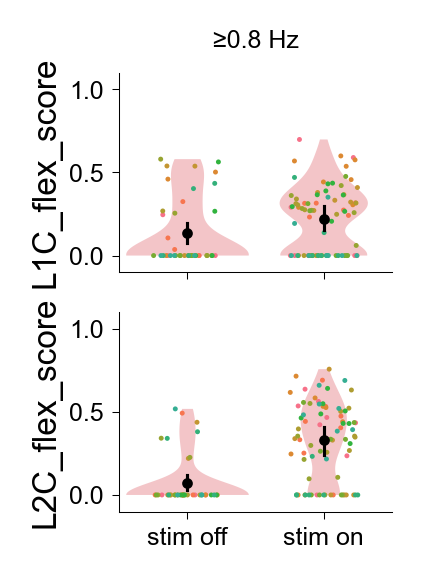

In [16]:
rhythmicityScores08 = compute_rhythmicity_scores(dnb08, minFreqHz=0.8)

feature1 = "L1C_flex_score"
feature2 = "L2C_flex_score"

fig, axes = plot_rhythmicity_violins(rhythmicityScores08, feature1, feature2, "≥0.8 Hz")

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/DNb08--violinPlots_{feature1}_{feature2}.svg",transparent=True)

In [17]:
l1StimOn, l1StimOff = paired_fly_means(rhythmicityScores08, "L1C_flex_score")
l2StimOn, l2StimOff = paired_fly_means(rhythmicityScores08, "L2C_flex_score")

print("L1C_flex:", stats.ttest_rel(l1StimOn, l1StimOff))
print("L2C_flex:", stats.ttest_rel(l2StimOn, l2StimOff))

L1C_flex: TtestResult(statistic=np.float64(2.457102562497609), pvalue=np.float64(0.036330930030072955), df=np.int64(9))
L2C_flex: TtestResult(statistic=np.float64(3.768341557259768), pvalue=np.float64(0.004427750101518952), df=np.int64(9))


*reanalyze with higher min frequency cutoff (1.0 Hz, the original `freq < 1/(len(x)/2)`)*


  0%|          | 0/240 [00:00<?, ?it/s]


  0%|          | 1/240 [00:00<00:42,  5.68it/s]


  1%|          | 2/240 [00:00<00:42,  5.57it/s]


  1%|▏         | 3/240 [00:00<00:43,  5.45it/s]


  2%|▏         | 4/240 [00:00<00:43,  5.43it/s]

...


 99%|█████████▉| 237/240 [00:28<00:00,  5.90it/s]


 99%|█████████▉| 238/240 [00:28<00:00,  5.58it/s]


100%|█████████▉| 239/240 [00:28<00:00,  5.51it/s]


100%|██████████| 240/240 [00:28<00:00,  5.30it/s]


100%|██████████| 240/240 [00:28<00:00,  8.32it/s]

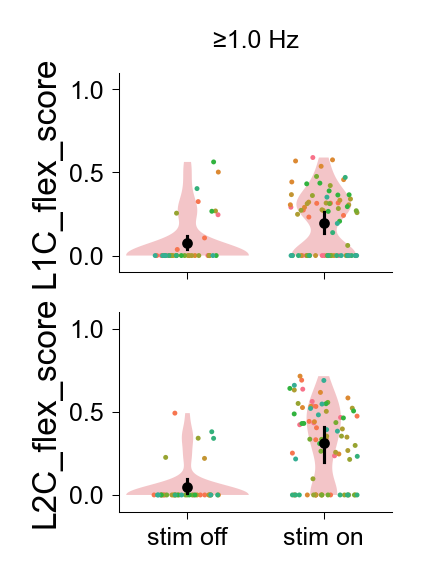

In [ ]:
rhythmicityScores10 = compute_rhythmicity_scores(dnb08, minFreqHz=1.0)

feature1 = "L1C_flex_score"
feature2 = "L2C_flex_score"

fig, axes = plot_rhythmicity_violins(rhythmicityScores10, feature1, feature2, "≥1.0 Hz")

if not os.path.exists(figFolder):
    os.makedirs(figFolder)
plt.savefig(figFolder+f"/DNb08--violinPlots_{feature1}_{feature2}_1Hz.svg",transparent=True)

In [19]:
l1StimOn, l1StimOff = paired_fly_means(rhythmicityScores10, "L1C_flex_score")
l2StimOn, l2StimOff = paired_fly_means(rhythmicityScores10, "L2C_flex_score")

print("L1C_flex:", stats.ttest_rel(l1StimOn, l1StimOff))
print("L2C_flex:", stats.ttest_rel(l2StimOn, l2StimOff))

L1C_flex: TtestResult(statistic=np.float64(4.7520132355738), pvalue=np.float64(0.0010412504438534482), df=np.int64(9))
L2C_flex: TtestResult(statistic=np.float64(3.6390320371216625), pvalue=np.float64(0.005409028580317279), df=np.int64(9))


100%|██████████| 240/240 [00:29<00:00,  8.07it/s]


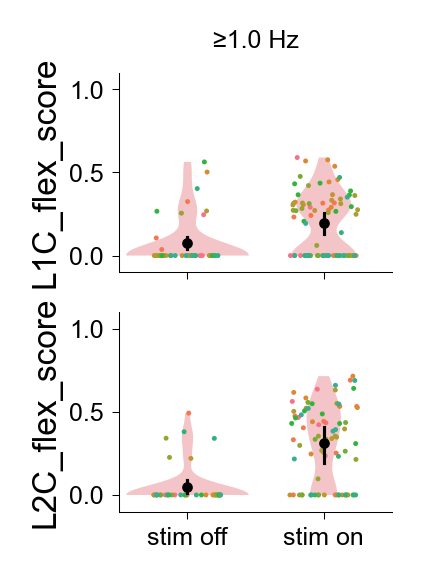

In [ ]:
rhythmicityScores10 = compute_rhythmicity_scores(dnb08, minFreqHz=1.0)

feature1 = "L1C_flex_score"
feature2 = "L2C_flex_score"

fig, axes = plot_rhythmicity_violins(rhythmicityScores10, feature1, feature2, None)

if not os.path.exists(figFolder):
    os.makedirs(figFolder)
plt.savefig(figFolder+f"/DNb08--violinPlots_{feature1}_{feature2}_1Hz.svg",transparent=True)

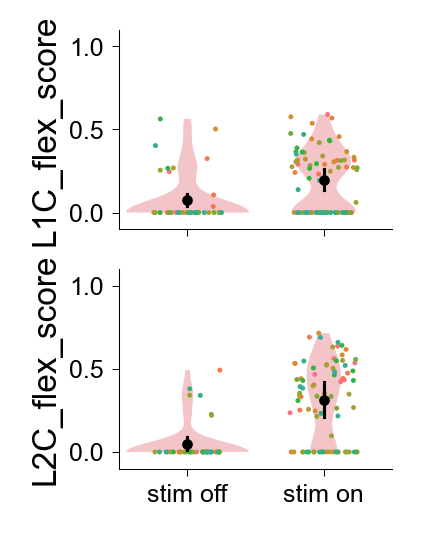

In [22]:
fig, axes = plot_rhythmicity_violins(rhythmicityScores10, feature1, feature2, None)

if not os.path.exists(figFolder):
    os.makedirs(figFolder)
plt.savefig(figFolder+f"/DNb08--violinPlots_{feature1}_{feature2}_1Hz.svg",transparent=True)